In [2]:
%pip install -e ..

Obtaining file:///C:/Users/jaspe/Documents/CLS/Thesis/research_core
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for research-core (pyproject.toml): started
  Building editable for research-core (pyproject.toml): finished with status 'done'
  Created wheel for research-core: filename=research_core-0.1.0-0.editable-py3-none-any.whl size=7256 sha256=fa73c478e9b471f779fbda51a1f947d1224f91e1601b0221677acfbc972ebc18
  Stored in directory: C:\Users\jaspe\AppData\Local\Temp\pip-ephem-wheel-cache-xaosscee\wheels\76\fd\76\e17d258147

DEPRECATION: pytorch-lightning 1.7.7 has a non-standard dependency specifier torch>=1.9.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pytorch-lightning or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063


In [3]:
from pathlib import Path
from research_core.classes import AnalyseMarket, helpers

# ─────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────

ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = ROOT / "data"

asset = "KGHM"
TICK_SIZE = 0.01

# ─────────────────────────────────────────────────────────────
# For REAL MARKET DATA (empirical order-flow database)
# ─────────────────────────────────────────────────────────────
db_path = OUTPUT_DIR / "KGHM_order_flow.sqlite"

am = AnalyseMarket(db_path, tick_size=TICK_SIZE)

# ─────────────────────────────────────────────────────────────
# For SIMULATION DATA, use the simulation database instead:
#   am = AnalyseMarket("sim_events.sqlite", tick_size=0.01)
# ─────────────────────────────────────────────────────────────

AnalyseMarket | KGHM_order_flow.sqlite | real data
  Tables: ['fills', 'mo_orders', 'orders']


# Empirical data for reference

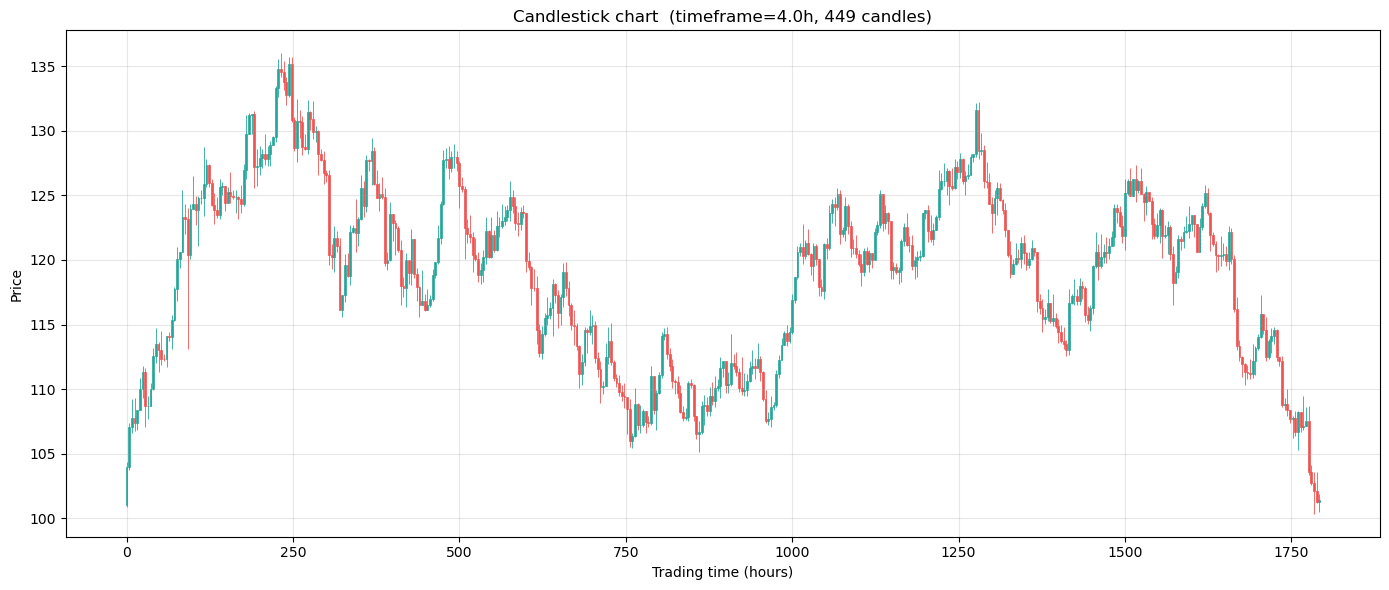

In [3]:
am.plot_candlestick(timeframe=14400.0)

Full sign series length: 612,612 MOs,  buy fraction: 0.517
Power-law exponent:  γ = 0.5445   (ρ(k) ~ k^{-0.5445})


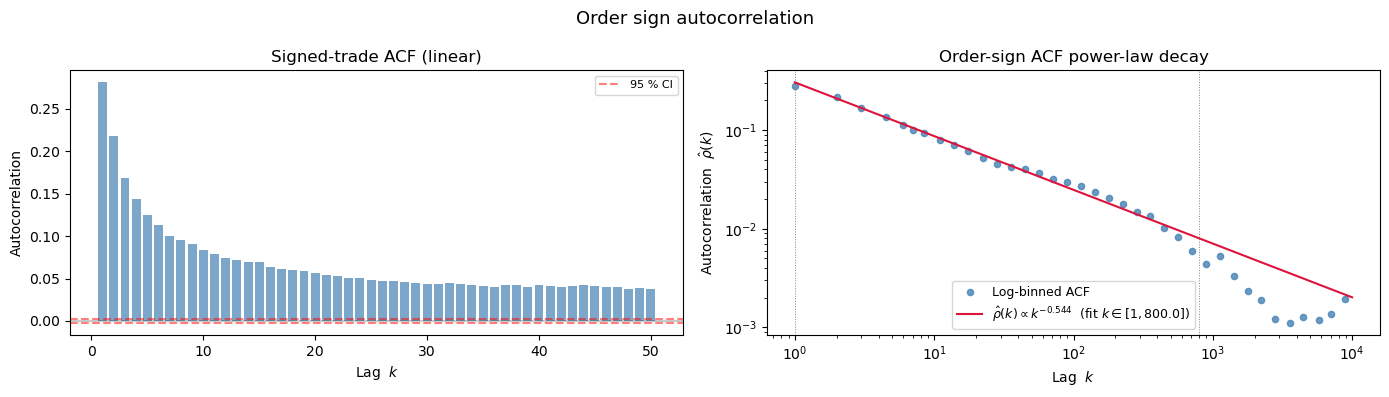

In [4]:
am.stylized_order_sign_autocorrelation(cap=800)

Loaded: sim_events_single_full_10M_9.sqlite


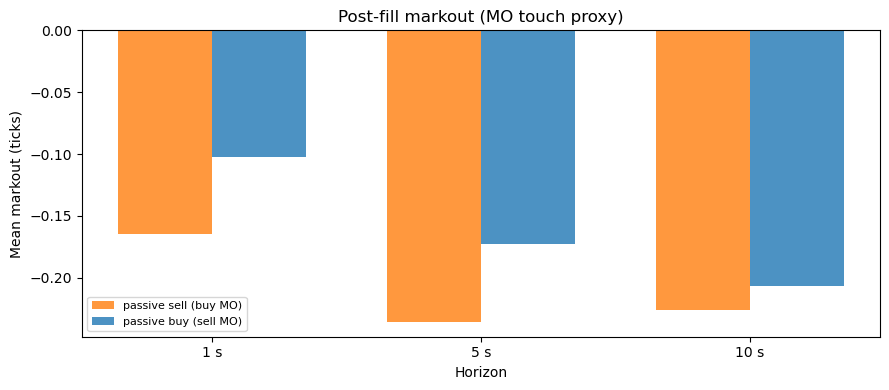

MO touch events: 30,558  (buy MO 15,474, sell MO 15,084)
Tick size: 0.05
  passive sell (buy MO)         τ=1s  n=15,474  mean=-0.1643 ticks
  passive buy (sell MO)         τ=1s  n=15,084  mean=-0.1026 ticks
  passive sell (buy MO)         τ=5s  n=15,474  mean=-0.2358 ticks
  passive buy (sell MO)         τ=5s  n=15,084  mean=-0.1728 ticks
  passive sell (buy MO)         τ=10s  n=15,474  mean=-0.2260 ticks
  passive buy (sell MO)         τ=10s  n=15,084  mean=-0.2069 ticks


{'tau_seconds': [1.0, 5.0, 10.0],
 'passive_sell_mean_ticks': [-0.1643401835336726,
  -0.23575029081039517,
  -0.22599198655810074],
 'passive_buy_mean_ticks': [-0.10259215062317678,
  -0.17283214001591096,
  -0.20687483426146908],
 'n_buy_mo': 15474,
 'n_sell_mo': 15084}

In [10]:
# ── Sub-minute return ACF — single-kernel spot check ─────────────────
# One of 60 single-kernel runs (10M / 10Ma families, i = 0..29 each).
from research_core.classes import AnalyseMarket, helpers

SINGLE_KERNEL_RUN = 9
DATA_DIR = helpers.project_root() / "data"
TICK_SIZE = 0.05

db_path = DATA_DIR / f"sim_events_single_full_10M_{SINGLE_KERNEL_RUN}.sqlite"
am_single = AnalyseMarket(db_path, tick_size=TICK_SIZE, verbose=False)
print(f"Loaded: {db_path.name}")

am_single.post_fill_markout(tau_seconds=(1, 5, 10))

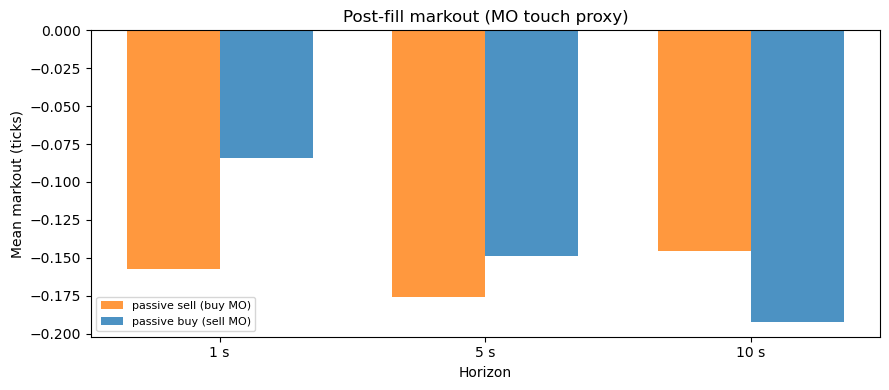

MO touch events: 30,072  (buy MO 15,278, sell MO 14,794)
Tick size: 0.05
  passive sell (buy MO)         τ=1s  n=15,278  mean=-0.1571 ticks
  passive buy (sell MO)         τ=1s  n=14,794  mean=-0.0840 ticks
  passive sell (buy MO)         τ=5s  n=15,278  mean=-0.1761 ticks
  passive buy (sell MO)         τ=5s  n=14,794  mean=-0.1486 ticks
  passive sell (buy MO)         τ=10s  n=15,278  mean=-0.1452 ticks
  passive buy (sell MO)         τ=10s  n=14,794  mean=-0.1924 ticks


{'tau_seconds': [1.0, 5.0, 10.0],
 'passive_sell_mean_ticks': [-0.1570886241654643,
  -0.17613561984552678,
  -0.14520879696295125],
 'passive_buy_mean_ticks': [-0.08395295390023388,
  -0.1485737461132922,
  -0.1924090847640953],
 'n_buy_mo': 15278,
 'n_sell_mo': 14794}

In [2]:
# Post-fill markout (MO touch proxy) — compare with empirical via analysis_empirical_data.ipynb
am_single.post_fill_markout(tau_seconds=(1, 5, 10))

# Multi-run Simulation Analysis

Aggregated stylized-facts analysis across 30 independent simulation runs.
Two extraction cells (BBO-based, MO-based) feed six lightweight plotting cells.

In [ ]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from research_core.classes import AnalyseMarket, helpers

# ── Configuration ─────────────────────────────────────────────────────
N_RUNS         = 30
TICK_SIZE      = 0.05
DATA_DIR       = helpers.project_root() / "data"

# Time-based resampling interval (seconds) for BBO-derived facts.
# Mid-prices are resampled onto a regular grid at this frequency
# using LOCF, and log-returns are computed from the resampled series.
RESAMPLE_DT    = 60.0  # seconds (1 minute)
DT_LABEL       = f"{RESAMPLE_DT/60:.0f}min" if RESAMPLE_DT >= 60 else f"{RESAMPLE_DT:.0f}s"

# Return ACF (lags in units of RESAMPLE_DT)
MAX_LAG_RET    = 50
# Volatility clustering ACF
MAX_LAG_VC     = 100
# Aggregational Gaussianity – multiples of RESAMPLE_DT
AGG_LEVELS     = [1, 5, 15, 30, 60, 120]

# Order sign ACF
MAX_LAG_BAR    = 50
MAX_LAG_LOGLOG = 10_000
N_LOG_BINS     = 40
FIT_CAP        = 800
# Price impact
N_BINS_IMPACT  = 20

db_paths = [DATA_DIR / f"sim_events_single_full_{i}.sqlite"
            for i in range(N_RUNS)]

missing = [p for p in db_paths if not p.exists()]
if missing:
    print(f"WARNING: {len(missing)} databases not found")
else:
    print(f"All {N_RUNS} simulation databases found.")

All 30 simulation databases found.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# BBO extraction — single pass per database
# ═══════════════════════════════════════════════════════════════════════

FT_MINUTES = 30  # matches stylized_fat_tails(interval_minutes=30): level np.diff(sampled)
INDIVIDUAL_RUNS = [0, 1]  # 2 representative runs shown per stylized fact


def _sample_mids_locf(ts_arr, mids_arr, interval_sec):
    """LOCF mids on a regular grid — same logic as AnalyseMarket._get_sampled_mid_prices,
    but reuses already-loaded (ts, mids) so each horizon does not re-query SQLite."""
    if interval_sec <= 0 or mids_arr is None or len(mids_arr) < 5:
        return None
    ts_arr = np.asarray(ts_arr, dtype=np.float64)
    mids_arr = np.asarray(mids_arr, dtype=np.float64)
    grid = np.arange(ts_arr[0], ts_arr[-1], interval_sec)
    if len(grid) < 2:
        return None
    idx = np.clip(
        np.searchsorted(ts_arr, grid, side="right") - 1,
        0, len(mids_arr) - 1,
    )
    return mids_arr[idx]


bbo = {
    "ft_kurtoses": [], "ft_changes": [],
    "acf_ret": [], "n_rets": [],
    "acf_abs": [], "acf_sq": [], "half_lives": [],
    "agg_kurtoses": [],
}

for i, p in enumerate(db_paths):
    print(f"\r  BBO {i+1}/{N_RUNS} ...", end="", flush=True)
    _am_run = AnalyseMarket(p, tick_size=TICK_SIZE, verbose=False)
    ts, mids = _am_run._get_mid_prices()
    if mids is None or len(mids) < 5:
        bbo["n_rets"].append(0)
        bbo["ft_kurtoses"].append(np.nan)
        bbo["ft_changes"].append(np.array([]))
        bbo["acf_ret"].append(np.array([]))
        bbo["acf_abs"].append(np.array([]))
        bbo["acf_sq"].append(np.array([]))
        bbo["half_lives"].append(np.nan)
        bbo["agg_kurtoses"].append([np.nan] * len(AGG_LEVELS))
        if i in INDIVIDUAL_RUNS:
            bbo.setdefault("agg_level_returns_individual", {})[i] = {
                int(agg): np.array([]) for agg in AGG_LEVELS}
        continue

    ts = np.asarray(ts, dtype=np.float64)
    mids = np.asarray(mids, dtype=np.float64)

    # ── Resample mid-prices onto a regular 1-min grid (LOCF) ─────
    t_grid = np.arange(ts[0], ts[-1], RESAMPLE_DT)
    idx_locf = np.searchsorted(ts, t_grid, side="right") - 1
    idx_locf = np.clip(idx_locf, 0, len(mids) - 1)
    mids_resampled = mids[idx_locf]

    log_mids = np.log(mids_resampled)
    rets = np.diff(log_mids)
    n = len(rets)
    bbo["n_rets"].append(n)

    # ── Fat tails — level ΔP (same as stylized_fat_tails default / aggregational)
    sampled_ft = _sample_mids_locf(ts, mids, float(FT_MINUTES) * 60.0)
    if sampled_ft is None or len(sampled_ft) < 3:
        bbo["ft_kurtoses"].append(np.nan)
        bbo["ft_changes"].append(np.array([]))
    else:
        changes = np.diff(np.asarray(sampled_ft, dtype=np.float64))
        changes = changes[np.isfinite(changes)]
        if len(changes) < 2 or changes.std() < 1e-15:
            bbo["ft_kurtoses"].append(np.nan)
            bbo["ft_changes"].append(changes)
        else:
            mu_ft, sigma_ft = changes.mean(), changes.std()
            kurt_ft = np.mean(((changes - mu_ft) / sigma_ft) ** 4) - 3.0
            bbo["ft_kurtoses"].append(kurt_ft)
            bbo["ft_changes"].append(changes)

    # ── Return ACF ────────────────────────────────────────────────
    mu = rets.mean()
    rets_dm = rets - mu
    var = np.dot(rets_dm, rets_dm)
    lags = np.arange(1, min(MAX_LAG_RET + 1, n))
    acf_r = np.array([np.dot(rets_dm[l:], rets_dm[:-l]) / var for l in lags])
    bbo["acf_ret"].append(acf_r)

    # ── Volatility clustering ─────────────────────────────────────
    acf_a = AnalyseMarket._acf(np.abs(rets), MAX_LAG_VC)
    acf_s = AnalyseMarket._acf(rets ** 2, MAX_LAG_VC)
    bbo["acf_abs"].append(acf_a)
    bbo["acf_sq"].append(acf_s)
    if acf_a[0] > 0:
        thr = acf_a[0] / np.e
        hl_idx = np.where(acf_a < thr)[0]
        bbo["half_lives"].append(hl_idx[0] + 1 if len(hl_idx) else MAX_LAG_VC)

    # ── Aggregational Gaussianity — level np.diff(sampled); horizons in minutes
    run_k = []
    indiv_agg = {}
    for agg in AGG_LEVELS:
        r = np.array([])
        sampled = _sample_mids_locf(ts, mids, float(agg) * 60.0)
        if sampled is None or len(sampled) < 25:
            run_k.append(np.nan)
        else:
            r = np.diff(np.asarray(sampled, dtype=np.float64))
            r = r[np.isfinite(r)]
            if len(r) < 20 or r.std() < 1e-15:
                run_k.append(np.nan)
            else:
                run_k.append(np.mean(((r - r.mean()) / r.std()) ** 4) - 3.0)
        if i in INDIVIDUAL_RUNS:
            indiv_agg[int(agg)] = r.copy() if r.size else np.array([])
    bbo["agg_kurtoses"].append(run_k)
    if i in INDIVIDUAL_RUNS:
        bbo.setdefault("agg_level_returns_individual", {})[i] = indiv_agg

    del ts, mids, mids_resampled, log_mids, rets

# Convert to arrays
bbo["n_rets"] = np.array(bbo["n_rets"])
bbo["ft_kurtoses"] = np.array(bbo["ft_kurtoses"])
bbo["ft_pooled"] = np.concatenate(bbo["ft_changes"])
bbo["ft_changes_individual"] = {r: bbo["ft_changes"][r] for r in INDIVIDUAL_RUNS}
del bbo["ft_changes"]
bbo["acf_ret"] = np.array(bbo["acf_ret"])
bbo["acf_abs"] = np.array(bbo["acf_abs"])
bbo["acf_sq"] = np.array(bbo["acf_sq"])
bbo["half_lives"] = np.array(bbo["half_lives"])
bbo["agg_kurtoses"] = np.array(bbo["agg_kurtoses"])

print(f"\n  Done — {len(bbo['ft_kurtoses'])} runs processed.")


  BBO 30/30 ...
  Done — 30 runs processed.


  Loading midprice 30/30 ...
  Done — 30 runs loaded.


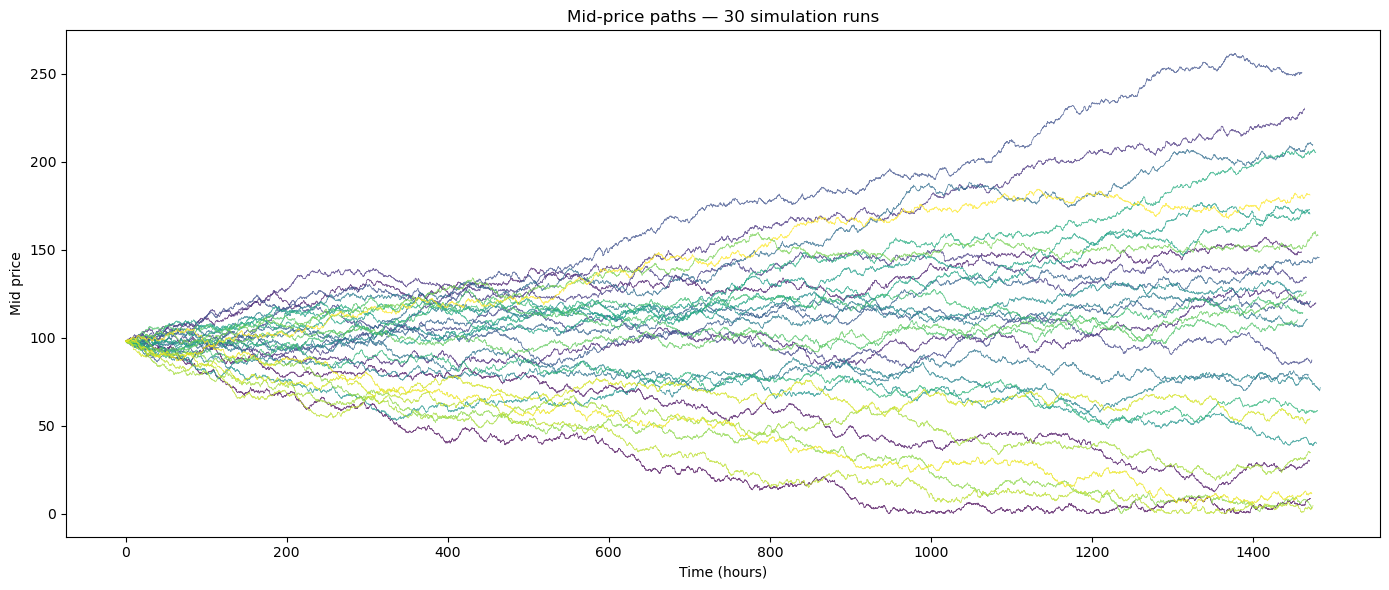

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# Mid-price paths — all 30 runs on a single plot
# ═══════════════════════════════════════════════════════════════════════

mid_series = {}
for i, p in enumerate(db_paths):
    if not p.exists():
        continue
    print(f"\r  Loading midprice {i+1}/{N_RUNS} ...", end="", flush=True)
    conn = sqlite3.connect(p)
    df = pd.read_sql("SELECT timestamp, mid_price FROM bbo ORDER BY timestamp", conn)
    conn.close()

    ts = df["timestamp"].values.astype(float)
    mids = df["mid_price"].values.astype(float)
    del df

    t_grid = np.arange(ts[0], ts[-1], RESAMPLE_DT)
    idx = np.clip(np.searchsorted(ts, t_grid, side="right") - 1, 0, len(mids) - 1)
    elapsed_min = (t_grid - ts[0]) / 60.0
    mid_series[i] = (elapsed_min, mids[idx])
    del ts, mids

print(f"\n  Done — {len(mid_series)} runs loaded.")

fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.viridis(np.linspace(0, 1, N_RUNS))
for i, (t, m) in mid_series.items():
    ax.plot(t / 60, m, lw=0.5, alpha=0.7, color=cmap[i])
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Mid price")
ax.set_title(f"Mid-price paths — {len(mid_series)} simulation runs")
plt.tight_layout()
plt.show()

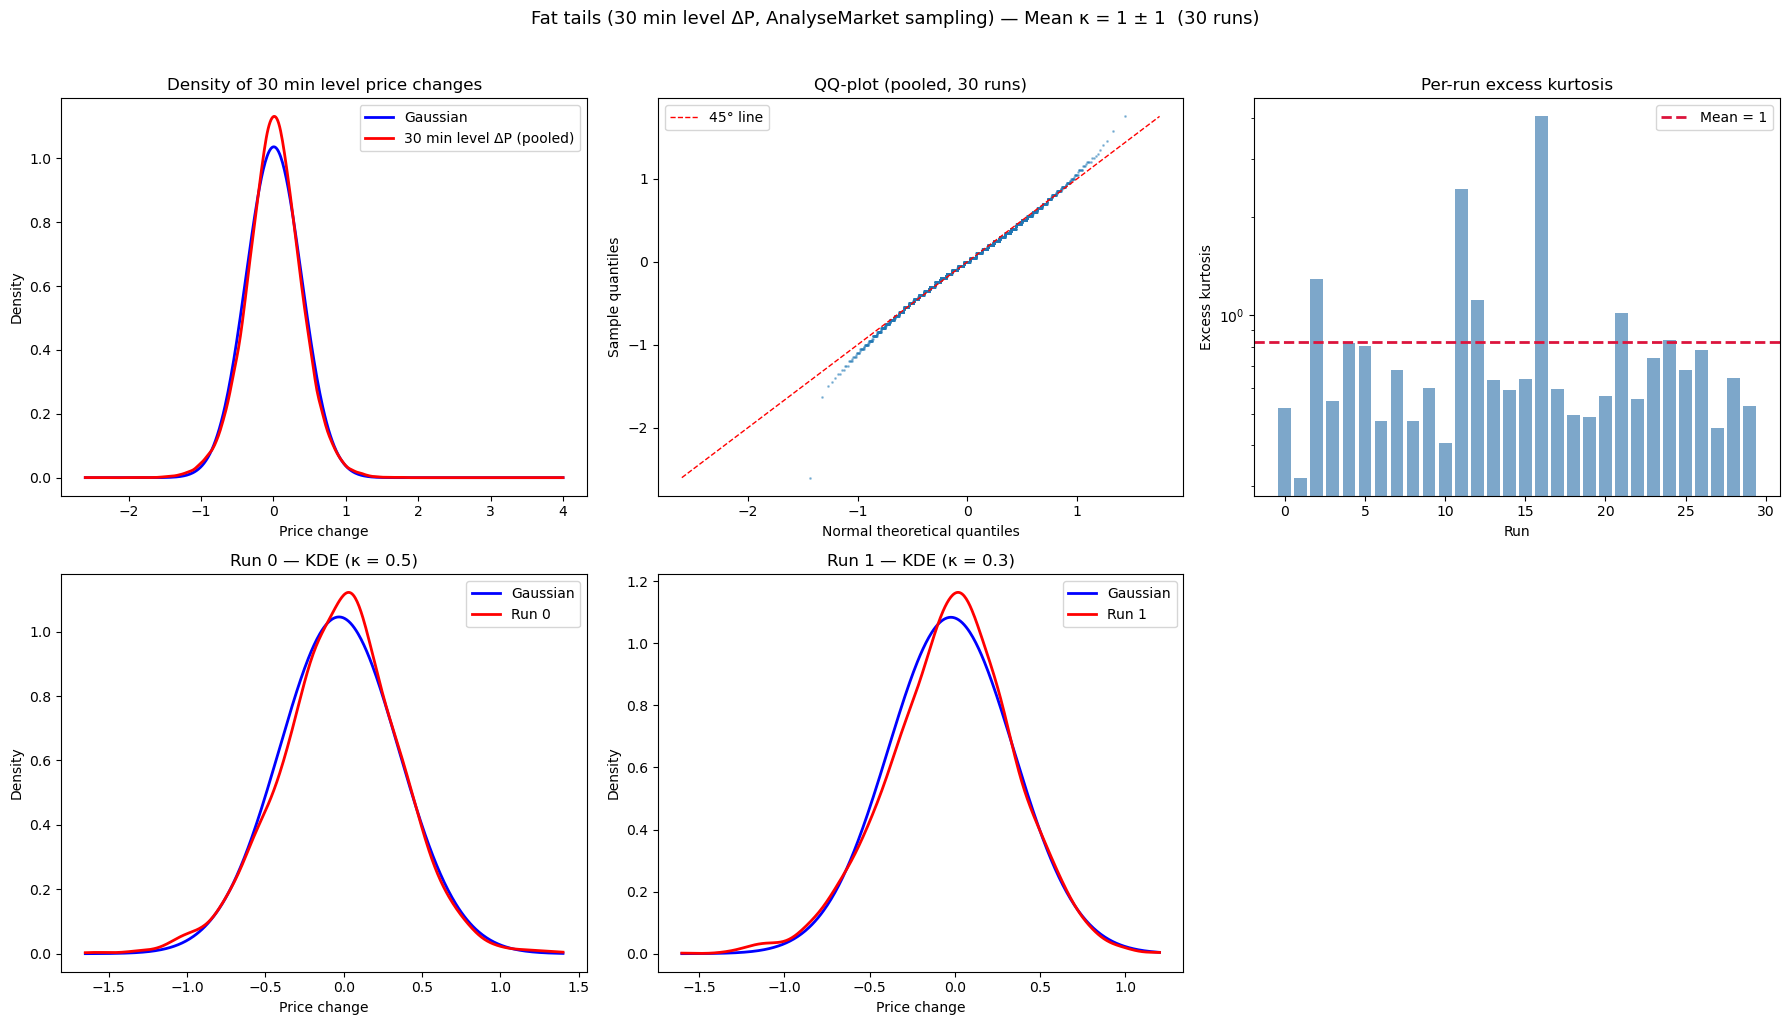

Per-run excess kurtosis: 1 ± 1  (min=0, max=4)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 1. Fat tails  (30-min level price changes — matches stylized_fat_tails / empirical)
# ═══════════════════════════════════════════════════════════════════════
from scipy.stats import gaussian_kde

pooled = bbo["ft_pooled"]
k = bbo["ft_kurtoses"]
mu_p, sigma_p = pooled.mean(), pooled.std()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── Row 1: aggregated 30-run view ──────────────────────────────────
ax = axes[0, 0]
kde = gaussian_kde(pooled)
x = np.linspace(pooled.min(), pooled.max(), 500)
ax.plot(x, norm.pdf(x, mu_p, sigma_p), "b-", lw=2, label="Gaussian")
ax.plot(x, kde(x), "r-", lw=2, label="30 min level ΔP (pooled)")
ax.set_xlabel("Price change"); ax.set_ylabel("Density")
ax.set_title("Density of 30 min level price changes"); ax.legend()

ax = axes[0, 1]
sr = np.sort(pooled)
step_qq = max(1, len(sr) // 5000)
sr_s = sr[::step_qq]; n_s = len(sr_s)
tq = np.array([mu_p + sigma_p * AnalyseMarket._ppf_normal((i + 0.5) / n_s)
               for i in range(n_s)])
ax.scatter(tq, sr_s, s=1, alpha=0.4)
lims = [min(tq.min(), sr_s.min()), max(tq.max(), sr_s.max())]
ax.plot(lims, lims, "r--", lw=1, label="45° line")
ax.set_xlabel("Normal theoretical quantiles")
ax.set_ylabel("Sample quantiles")
ax.set_title(f"QQ-plot (pooled, {N_RUNS} runs)"); ax.legend()

ax = axes[0, 2]
ax.bar(range(len(k)), k, alpha=0.7, color="steelblue")
ax.axhline(k.mean(), color="crimson", lw=2, ls="--",
           label=f"Mean = {k.mean():.0f}")
ax.set_yscale("log")
ax.set_xlabel("Run"); ax.set_ylabel("Excess kurtosis")
ax.set_title("Per-run excess kurtosis"); ax.legend()

# ── Row 2: individual run analysis (2 runs) ────────────────────────
for col, run_idx in enumerate(INDIVIDUAL_RUNS):
    changes = bbo["ft_changes_individual"][run_idx]
    mu_i, sig_i = changes.mean(), changes.std()
    kurt_i = bbo["ft_kurtoses"][run_idx]

    ax = axes[1, col]
    kde_i = gaussian_kde(changes)
    x_i = np.linspace(changes.min(), changes.max(), 500)
    ax.plot(x_i, norm.pdf(x_i, mu_i, sig_i), "b-", lw=2, label="Gaussian")
    ax.plot(x_i, kde_i(x_i), "r-", lw=2, label=f"Run {run_idx}")
    ax.set_xlabel("Price change"); ax.set_ylabel("Density")
    ax.set_title(f"Run {run_idx} — KDE (κ = {kurt_i:.1f})"); ax.legend()

# hide unused subplot in row 2
axes[1, 2].set_visible(False)

plt.suptitle(f"Fat tails (30 min level ΔP, AnalyseMarket sampling) — Mean κ = {k.mean():.0f} ± {k.std():.0f}  "
             f"({len(k)} runs)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"Per-run excess kurtosis: {k.mean():.0f} ± {k.std():.0f}  "
      f"(min={k.min():.0f}, max={k.max():.0f})")


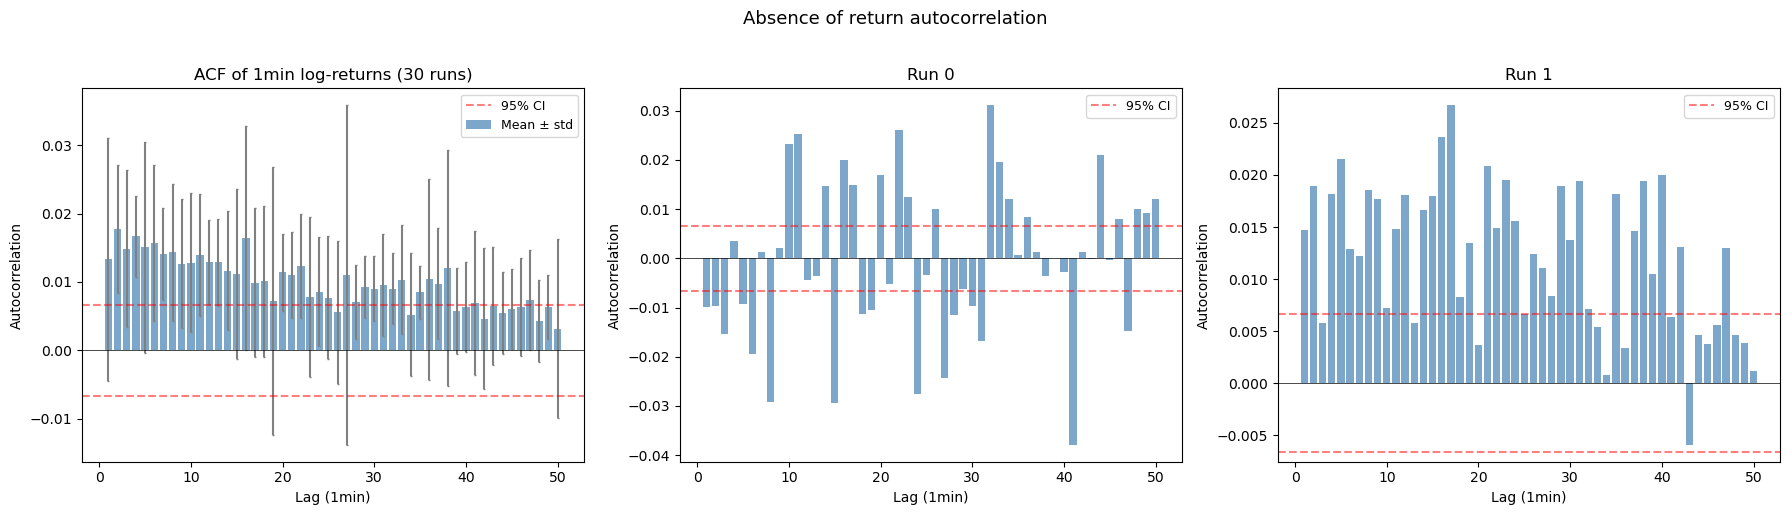

Mean |ACF| across lags 1–50: 0.011727 ± 0.003949


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 2. Absence of return autocorrelation
# ═══════════════════════════════════════════════════════════════════════

acf_ret = bbo["acf_ret"]
mean_acf = acf_ret.mean(axis=0)
std_acf = acf_ret.std(axis=0)
lags = np.arange(1, len(mean_acf) + 1)
ci = 1.96 / np.sqrt(bbo["n_rets"].mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Panel 1: aggregated mean ± std ─────────────────────────────────
ax = axes[0]
ax.bar(lags, mean_acf, width=0.8, alpha=0.7, color="steelblue",
       yerr=std_acf, capsize=1, ecolor="grey", label="Mean ± std")
ax.axhline(ci,  ls="--", color="red", alpha=0.5, label="95% CI")
ax.axhline(-ci, ls="--", color="red", alpha=0.5)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel(f"Lag ({DT_LABEL})"); ax.set_ylabel("Autocorrelation")
ax.set_title(f"ACF of {DT_LABEL} log-returns ({len(acf_ret)} runs)")
ax.legend(fontsize=9)

# ── Panels 2-3: individual runs ────────────────────────────────────
for col, run_idx in enumerate(INDIVIDUAL_RUNS):
    ax = axes[1 + col]
    ci_i = 1.96 / np.sqrt(bbo["n_rets"][run_idx])
    ax.bar(lags, acf_ret[run_idx], width=0.8, alpha=0.7, color="steelblue")
    ax.axhline(ci_i,  ls="--", color="red", alpha=0.5, label="95% CI")
    ax.axhline(-ci_i, ls="--", color="red", alpha=0.5)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel(f"Lag ({DT_LABEL})"); ax.set_ylabel("Autocorrelation")
    ax.set_title(f"Run {run_idx}"); ax.legend(fontsize=9)

plt.suptitle("Absence of return autocorrelation", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

mean_abs_acf = np.array([np.abs(a).mean() for a in acf_ret])
print(f"Mean |ACF| across lags 1–{MAX_LAG_RET}: "
      f"{mean_abs_acf.mean():.6f} ± {mean_abs_acf.std():.6f}")

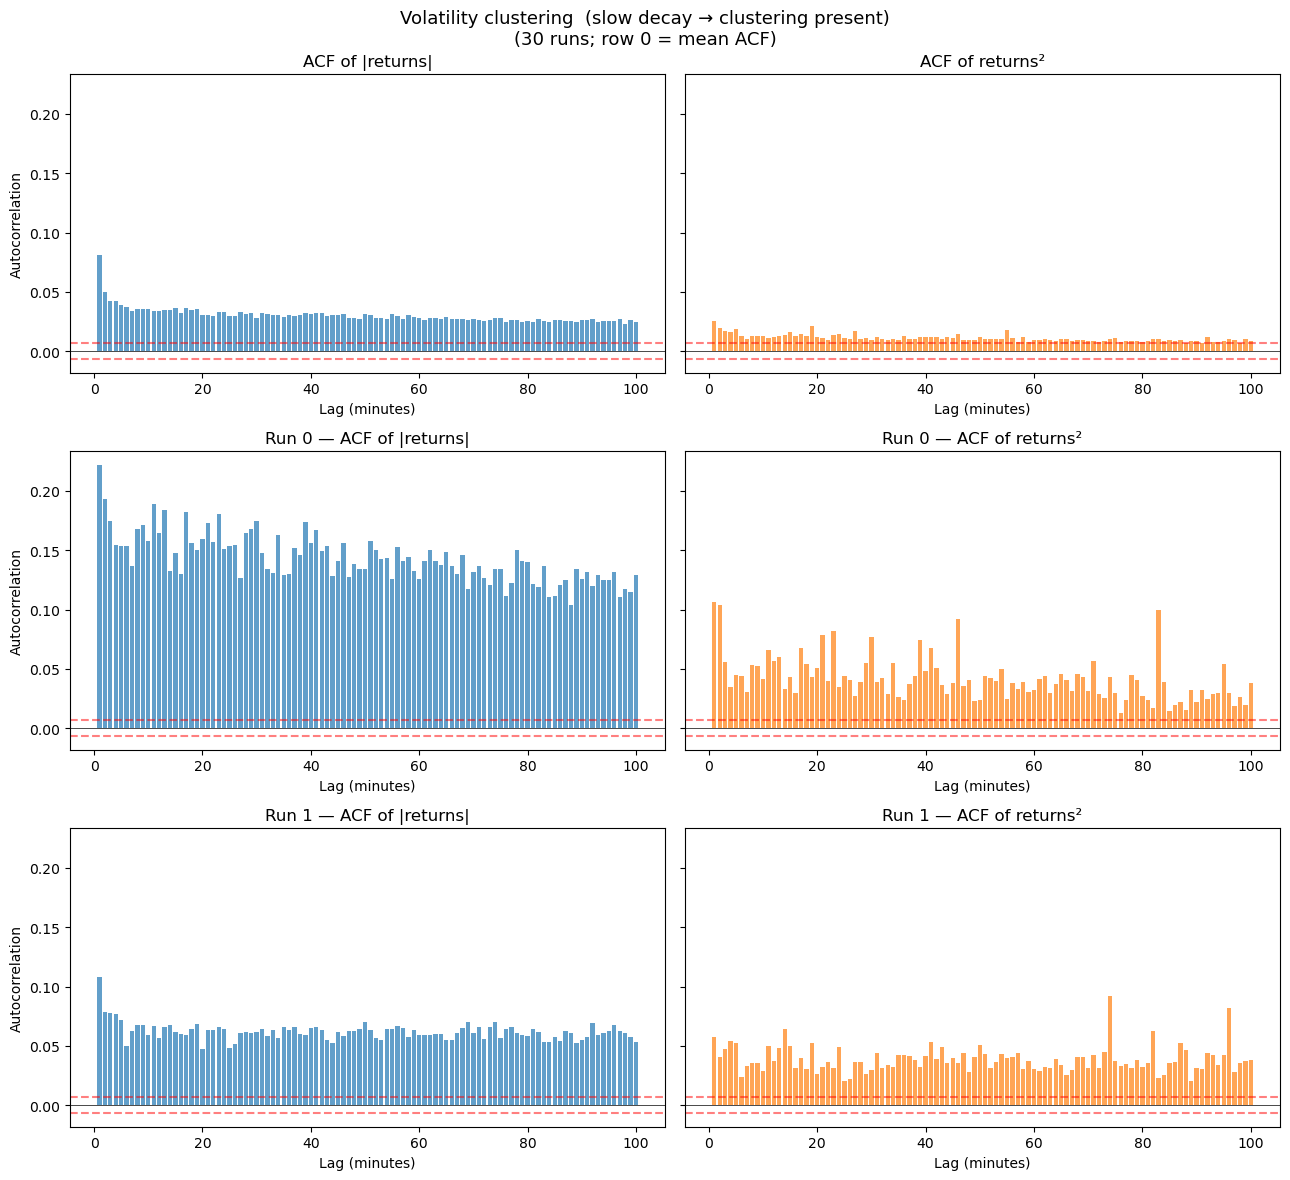

|returns| ACF half-life: 20.5 ± 35.7 1min  (min=2, max=100 1min)
|returns| ACF(1):  0.0811 ± 0.0517
|returns| ACF(10): 0.0357 ± 0.0451


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 3. Volatility clustering (same layout as empirical: linear axes, bar ACF)
# ═══════════════════════════════════════════════════════════════════════

mean_abs = bbo["acf_abs"].mean(axis=0)
std_abs  = bbo["acf_abs"].std(axis=0)
mean_sq  = bbo["acf_sq"].mean(axis=0)
std_sq   = bbo["acf_sq"].std(axis=0)

interval_min = RESAMPLE_DT / 60.0  # minutes per lag (matches empirical interval_minutes)
lag_minutes = np.arange(1, len(mean_abs) + 1) * interval_min
bar_w = interval_min * 0.8
ci_mean_n = 1.96 / np.sqrt(bbo["n_rets"].mean())

n_ind = len(INDIVIDUAL_RUNS)
fig, axes = plt.subplots(1 + n_ind, 2, figsize=(13, 5 + 3.5 * n_ind), sharey=True)

# ── Row 0: mean ACF across runs (bars + asymptotic band, like empirical) ──
ax = axes[0, 0]
ax.bar(lag_minutes, mean_abs, width=bar_w, alpha=0.7, color="tab:blue")
ax.axhline(ci_mean_n, ls="--", color="red", alpha=0.5)
ax.axhline(-ci_mean_n, ls="--", color="red", alpha=0.5)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Lag (minutes)")
ax.set_ylabel("Autocorrelation")
ax.set_title("ACF of |returns|")

ax = axes[0, 1]
ax.bar(lag_minutes, mean_sq, width=bar_w, alpha=0.7, color="tab:orange")
ax.axhline(ci_mean_n, ls="--", color="red", alpha=0.5)
ax.axhline(-ci_mean_n, ls="--", color="red", alpha=0.5)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Lag (minutes)")
ax.set_title("ACF of returns²")

# ── Rows 1+: individual runs ─────────────────────────────────────────
for row, run_idx in enumerate(INDIVIDUAL_RUNS):
    ci_i = 1.96 / np.sqrt(bbo["n_rets"][run_idx])
    ax = axes[1 + row, 0]
    ax.bar(lag_minutes, bbo["acf_abs"][run_idx], width=bar_w, alpha=0.7, color="tab:blue")
    ax.axhline(ci_i, ls="--", color="red", alpha=0.5)
    ax.axhline(-ci_i, ls="--", color="red", alpha=0.5)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("Lag (minutes)")
    ax.set_ylabel("Autocorrelation")
    ax.set_title(f"Run {run_idx} — ACF of |returns|")

    ax = axes[1 + row, 1]
    ax.bar(lag_minutes, bbo["acf_sq"][run_idx], width=bar_w, alpha=0.7, color="tab:orange")
    ax.axhline(ci_i, ls="--", color="red", alpha=0.5)
    ax.axhline(-ci_i, ls="--", color="red", alpha=0.5)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("Lag (minutes)")
    ax.set_title(f"Run {run_idx} — ACF of returns²")

hl = bbo["half_lives"]
plt.suptitle(
    "Volatility clustering  (slow decay → clustering present)\n"
    f"({len(bbo['acf_abs'])} runs; row 0 = mean ACF)",
    fontsize=13,
)
plt.tight_layout(); plt.show()

print(f"|returns| ACF half-life: {hl.mean():.1f} ± {hl.std():.1f} {DT_LABEL}  "
      f"(min={hl.min():.0f}, max={hl.max():.0f} {DT_LABEL})")
print(f"|returns| ACF(1):  {mean_abs[0]:.4f} ± {std_abs[0]:.4f}")
print(f"|returns| ACF(10): {mean_abs[9]:.4f} ± {std_abs[9]:.4f}")

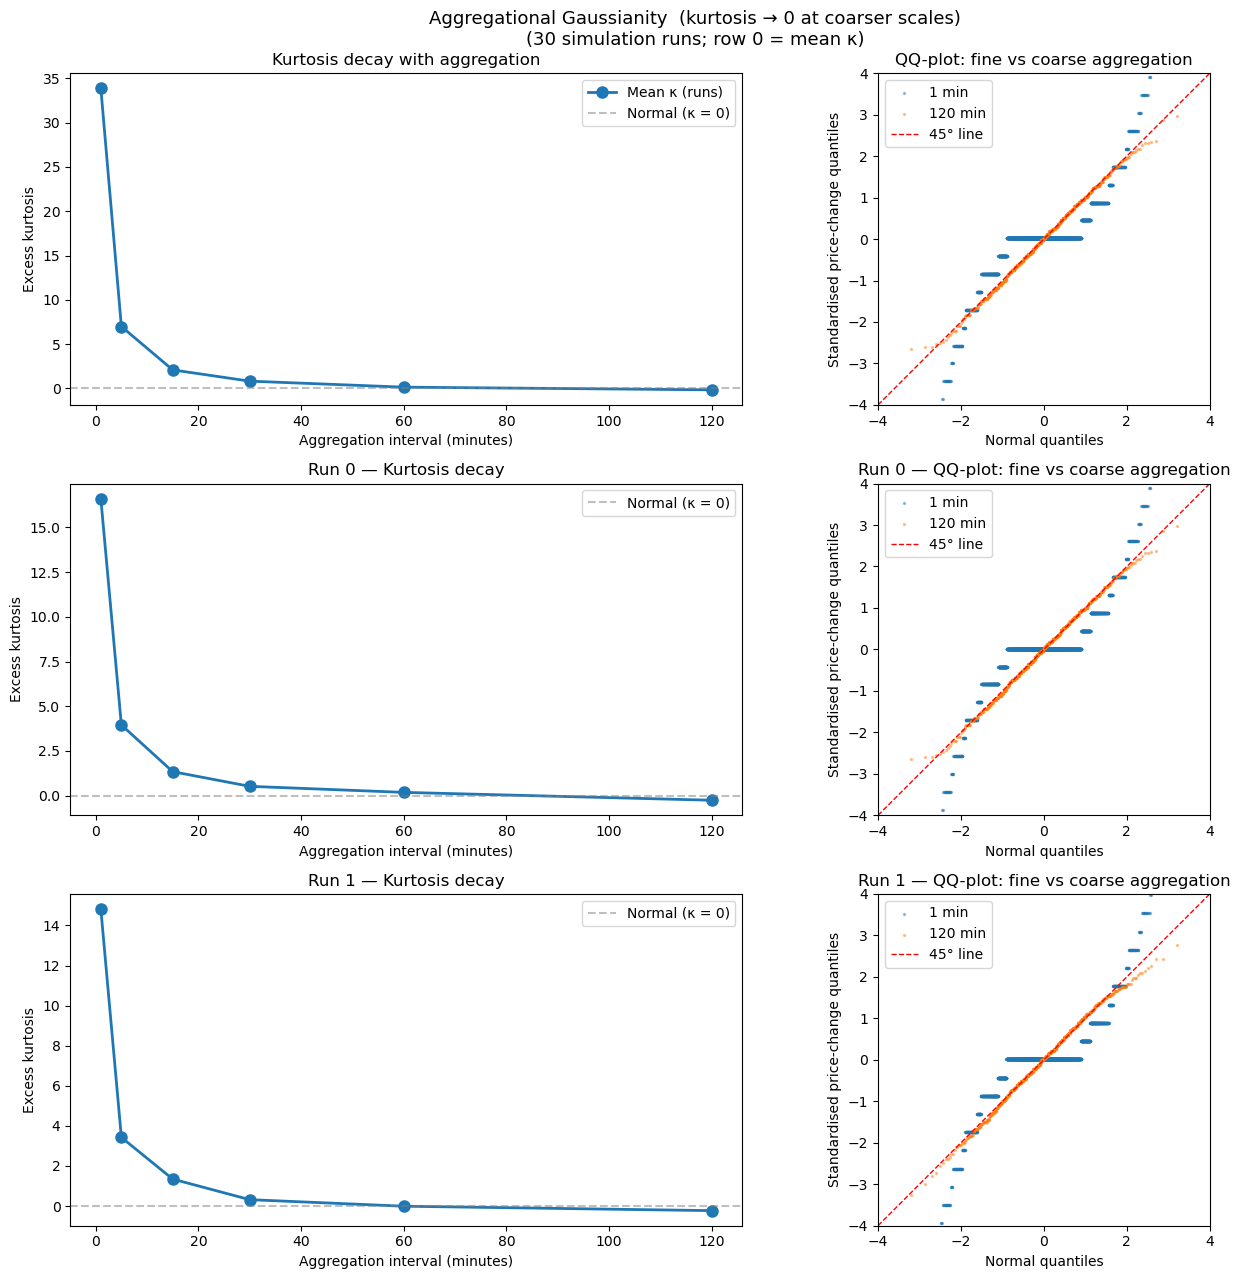

  agg=   1 1min:  κ = +33.89 ± 42.00
  agg=   5 1min:  κ = +6.99 ± 7.94
  agg=  15 1min:  κ = +2.09 ± 1.94
  agg=  30 1min:  κ = +0.83 ± 0.71
  agg=  60 1min:  κ = +0.15 ± 0.27
  agg= 120 1min:  κ = -0.16 ± 0.17


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 4. Aggregational Gaussianity
# ═══════════════════════════════════════════════════════════════════════

ak = bbo["agg_kurtoses"]
mean_k = np.nanmean(ak, axis=0)
std_k  = np.nanstd(ak, axis=0)

n_ind = len(INDIVIDUAL_RUNS)
fig, axes = plt.subplots(1 + n_ind, 2, figsize=(14, 5 + 4 * n_ind))

# ── Row 0: aggregated (same layout as empirical stylized_aggregational_gaussianity)
ax = axes[0, 0]
ax.plot(AGG_LEVELS, mean_k, "o-", lw=2, ms=8, color="C0", label="Mean κ (runs)")
ax.axhline(0, ls="--", color="grey", alpha=0.5, label="Normal (κ = 0)")
ax.set_xlabel("Aggregation interval (minutes)")
ax.set_ylabel("Excess kurtosis")
ax.set_title("Kurtosis decay with aggregation")
ax.legend()

ax = axes[0, 1]
cache0 = bbo["agg_level_returns_individual"][INDIVIDUAL_RUNS[0]]
for agg, lbl, col in [(AGG_LEVELS[0],  f"{AGG_LEVELS[0]} min",  "tab:blue"),
                       (AGG_LEVELS[-1], f"{AGG_LEVELS[-1]} min", "tab:orange")]:
    r = cache0.get(int(agg), np.array([]))
    if r.size < 5:
        continue
    mu_r, sig_r = r.mean(), r.std()
    if sig_r < 1e-15:
        continue
    sr = np.sort((r - mu_r) / sig_r)
    step = max(1, len(sr) // 3000)
    sr_s = sr[::step]; nn = len(sr_s)
    th = np.array([AnalyseMarket._ppf_normal((i + 0.5) / nn)
                   for i in range(nn)])
    ax.scatter(th, sr_s, s=2, alpha=0.4, color=col, label=lbl)
ax.plot([-4, 4], [-4, 4], "r--", lw=1, label="45° line")
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Normal quantiles")
ax.set_ylabel("Standardised price-change quantiles")
ax.set_title("QQ-plot: fine vs coarse aggregation")
ax.legend()


# ── Rows 1+: individual runs ──────────────────────────────────────
for row, run_idx in enumerate(INDIVIDUAL_RUNS):
    ax = axes[1 + row, 0]
    run_k = ak[run_idx]
    ax.plot(AGG_LEVELS, run_k, "o-", lw=2, ms=8, color="C0")
    ax.axhline(0, ls="--", color="grey", alpha=0.5, label="Normal (κ = 0)")
    ax.set_xlabel("Aggregation interval (minutes)")
    ax.set_ylabel("Excess kurtosis")
    ax.set_title(f"Run {run_idx} — Kurtosis decay")
    ax.legend()

    ax = axes[1 + row, 1]
    cache = bbo["agg_level_returns_individual"][run_idx]
    for agg, lbl, col in [(AGG_LEVELS[0],  f"{AGG_LEVELS[0]} min",  "tab:blue"),
                           (AGG_LEVELS[-1], f"{AGG_LEVELS[-1]} min", "tab:orange")]:
        r = cache.get(int(agg), np.array([]))
        if r.size < 5:
            continue
        mu_r, sig_r = r.mean(), r.std()
        if sig_r < 1e-15:
            continue
        sr = np.sort((r - mu_r) / sig_r)
        step = max(1, len(sr) // 3000)
        sr_s = sr[::step]; nn = len(sr_s)
        th = np.array([AnalyseMarket._ppf_normal((i + 0.5) / nn)
                       for i in range(nn)])
        ax.scatter(th, sr_s, s=2, alpha=0.4, color=col, label=lbl)
    ax.plot([-4, 4], [-4, 4], "r--", lw=1, label="45° line")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Normal quantiles")
    ax.set_ylabel("Standardised price-change quantiles")
    ax.set_title(f"Run {run_idx} — QQ-plot: fine vs coarse aggregation")
    ax.legend()

plt.suptitle(
    "Aggregational Gaussianity  (kurtosis → 0 at coarser scales)\n"
    f"({len(ak)} simulation runs; row 0 = mean κ)",
    fontsize=13,
)
plt.tight_layout(); plt.show()

for lvl, mk, sk in zip(AGG_LEVELS, mean_k, std_k):
    print(f"  agg={lvl:>4d} {DT_LABEL}:  κ = {mk:+.2f} ± {sk:.2f}")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# MO extraction — single pass per database
# ═══════════════════════════════════════════════════════════════════════

mo = {
    "acf_short": [], "acf_long": [],
    "gammas": [], "n_mos": [],
    "deltas": [],
    "pooled_sizes": [], "pooled_tw": [],
}

for i, p in enumerate(db_paths):
    print(f"\r  MO {i+1}/{N_RUNS} ...", end="", flush=True)
    conn = sqlite3.connect(p)

    # ── Order sign ACF ────────────────────────────────────────────
    df_sign = pd.read_sql(
        "SELECT side FROM mo_orders ORDER BY timestamp", conn)
    signs = np.where(df_sign["side"].values == "buy", 1.0, -1.0)
    n_mo = len(signs)
    mo["n_mos"].append(n_mo)

    acf_full = AnalyseMarket._acf_fft(signs, MAX_LAG_LOGLOG)
    mo["acf_short"].append(acf_full[1:MAX_LAG_BAR + 1])
    mo["acf_long"].append(acf_full[1:])

    # Per-run gamma via log-binned OLS
    lags_ll = np.arange(1, MAX_LAG_LOGLOG + 1, dtype=float)
    acf_vals = acf_full[1:]
    pos = acf_vals > 0
    gamma = np.nan
    if pos.sum() >= 10:
        lags_pos = lags_ll[pos]
        acf_pos  = acf_vals[pos]
        edges = np.unique(np.logspace(
            np.log10(1), np.log10(lags_pos.max()), N_LOG_BINS + 1))
        lb, ab = [], []
        for j in range(len(edges) - 1):
            lo, hi = edges[j], edges[j + 1]
            m = ((lags_pos >= lo) & (lags_pos < hi) if j < len(edges) - 2
                 else (lags_pos >= lo) & (lags_pos <= hi))
            if m.sum() == 0:
                continue
            lb.append(np.exp(np.mean(np.log(lags_pos[m]))))
            ab.append(acf_pos[m].mean())
        lb, ab = np.array(lb), np.array(ab)
        fm = (lb >= 1) & (lb <= FIT_CAP) & (ab > 0)
        if fm.sum() >= 5:
            log_l = np.log(lb[fm])
            log_a = np.log(ab[fm])
            A = np.column_stack([np.ones_like(log_l), log_l])
            gamma = -np.linalg.lstsq(A, log_a, rcond=None)[0][1]
    mo["gammas"].append(gamma)

    # ── Price impact ──────────────────────────────────────────────
    df_pi = pd.read_sql(
        "SELECT mo_volume, ticks_walked FROM mo_orders "
        "WHERE mo_volume IS NOT NULL AND mo_volume > 0 "
        "  AND ticks_walked IS NOT NULL", conn)
    conn.close()

    sizes = df_pi["mo_volume"].values.astype(float)
    tw    = df_pi["ticks_walked"].values.astype(float)

    # Per-run delta
    pcts = np.linspace(0, 100, N_BINS_IMPACT + 1)
    bin_edges = np.unique(np.percentile(sizes, pcts))
    bi = np.clip(np.digitize(sizes, bin_edges) - 1, 0, len(bin_edges) - 2)
    ms_r, mi_r = [], []
    for b in range(len(bin_edges) - 1):
        mask = bi == b
        if mask.sum() < 5:
            continue
        ms_r.append(sizes[mask].mean())
        mi_r.append(tw[mask].mean())
    ms_r, mi_r = np.array(ms_r), np.array(mi_r)
    delta = np.nan
    pos_d = mi_r > 0
    if pos_d.sum() >= 2:
        coef = np.polyfit(np.log10(ms_r[pos_d]), np.log10(mi_r[pos_d]), 1)
        delta = coef[0]
    mo["deltas"].append(delta)

    # Subsample for pooled visualisation
    idx = np.random.choice(len(sizes), min(5000, len(sizes)), replace=False)
    mo["pooled_sizes"].append(sizes[idx])
    mo["pooled_tw"].append(tw[idx])

    # keep per-run data for individual run plots
    if i in INDIVIDUAL_RUNS:
        mo.setdefault("signs_individual", {})[i] = signs.copy()
        mo.setdefault("sizes_individual", {})[i] = sizes.copy()
        mo.setdefault("tw_individual", {})[i] = tw.copy()

    del df_sign, df_pi, signs, sizes, tw

# Convert to arrays
mo["acf_short"]    = np.array(mo["acf_short"])
mo["acf_long"]     = np.array(mo["acf_long"])
mo["gammas"]       = np.array(mo["gammas"])
mo["n_mos"]        = np.array(mo["n_mos"])
mo["deltas"]       = np.array(mo["deltas"])
mo["pooled_sizes"] = np.concatenate(mo["pooled_sizes"])
mo["pooled_tw"]    = np.concatenate(mo["pooled_tw"])

print(f"\n  Done — {N_RUNS} runs processed.")

  MO 30/30 ...
  Done — 30 runs processed.


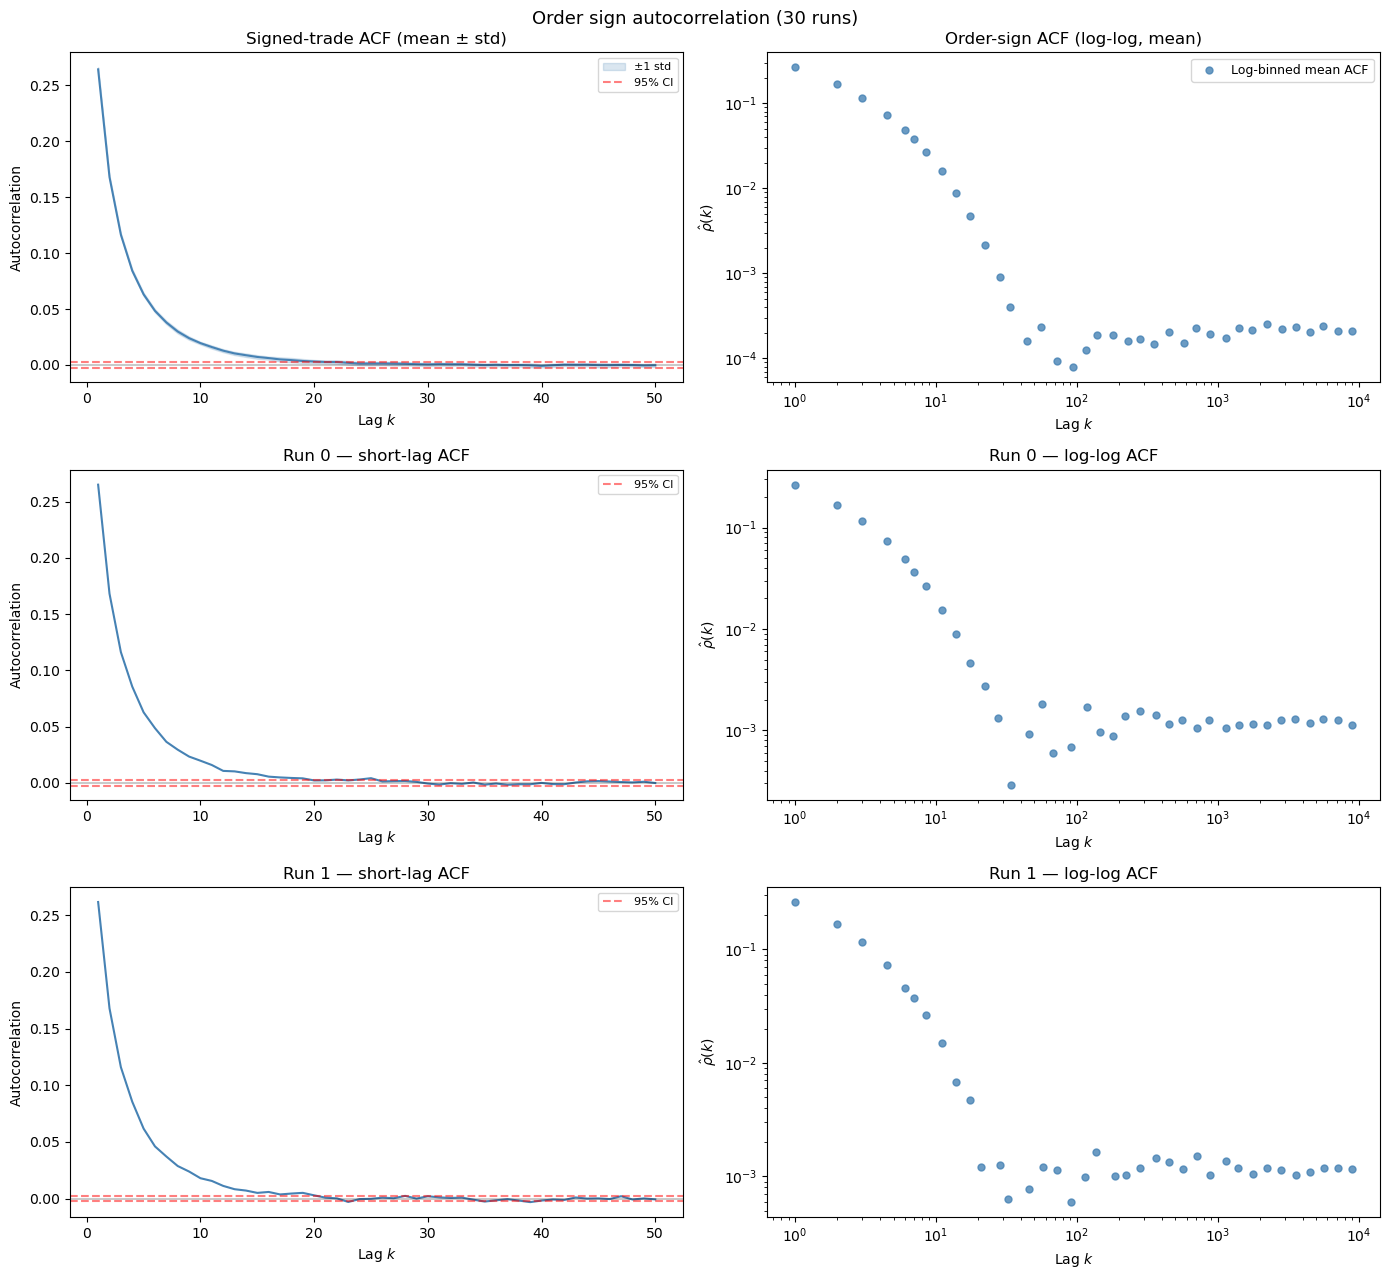

Average MO count: 553,208
Sign ACF(1):  0.2644 ± 0.0018
Sign ACF(10): 0.0195 ± 0.0012


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 5. Order sign autocorrelation (long memory)
# ═══════════════════════════════════════════════════════════════════════

mean_short = mo["acf_short"].mean(axis=0)
std_short  = mo["acf_short"].std(axis=0)
mean_long  = mo["acf_long"].mean(axis=0)
avg_n_mo   = mo["n_mos"].mean()
ci_mo      = 1.96 / np.sqrt(avg_n_mo)

n_ind = len(INDIVIDUAL_RUNS)
fig, axes = plt.subplots(1 + n_ind, 2, figsize=(14, 5 + 4 * n_ind))

# ── Row 0: aggregated ──────────────────────────────────────────────
lags_s = np.arange(1, MAX_LAG_BAR + 1)
ax = axes[0, 0]
ax.plot(lags_s, mean_short, lw=1.5, color="steelblue")
ax.fill_between(lags_s, mean_short - std_short, mean_short + std_short,
                alpha=0.2, color="steelblue", label="±1 std")
ax.axhline(ci_mo,  ls="--", color="red", alpha=0.5, label="95% CI")
ax.axhline(-ci_mo, ls="--", color="red", alpha=0.5)
ax.axhline(0, lw=0.3, color="k")
ax.set_xlabel("Lag $k$"); ax.set_ylabel("Autocorrelation")
ax.set_title("Signed-trade ACF (mean ± std)"); ax.legend(fontsize=8)

ax = axes[0, 1]
lags_ll = np.arange(1, MAX_LAG_LOGLOG + 1, dtype=float)
pos = mean_long > 0
if pos.sum() >= 10:
    lags_pos = lags_ll[pos]
    acf_pos  = mean_long[pos]
    edges = np.unique(np.logspace(
        np.log10(1), np.log10(lags_pos.max()), N_LOG_BINS + 1))
    lb, ab = [], []
    for j in range(len(edges) - 1):
        lo, hi = edges[j], edges[j + 1]
        m = ((lags_pos >= lo) & (lags_pos < hi) if j < len(edges) - 2
             else (lags_pos >= lo) & (lags_pos <= hi))
        if m.sum() == 0:
            continue
        lb.append(np.exp(np.mean(np.log(lags_pos[m]))))
        ab.append(acf_pos[m].mean())
    lb, ab = np.array(lb), np.array(ab)
    ax.scatter(lb, ab, s=25, alpha=0.8, color="steelblue",
               label="Log-binned mean ACF")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Lag $k$"); ax.set_ylabel(r"$\hat\rho(k)$")
ax.set_title("Order-sign ACF (log-log, mean)"); ax.legend(fontsize=9)

# ── Rows 1+: individual runs ──────────────────────────────────────
for row, run_idx in enumerate(INDIVIDUAL_RUNS):
    ci_i = 1.96 / np.sqrt(mo["n_mos"][run_idx])

    ax = axes[1 + row, 0]
    ax.plot(lags_s, mo["acf_short"][run_idx], lw=1.5, color="steelblue")
    ax.axhline(ci_i,  ls="--", color="red", alpha=0.5, label="95% CI")
    ax.axhline(-ci_i, ls="--", color="red", alpha=0.5)
    ax.axhline(0, lw=0.3, color="k")
    ax.set_xlabel("Lag $k$"); ax.set_ylabel("Autocorrelation")
    ax.set_title(f"Run {run_idx} — short-lag ACF"); ax.legend(fontsize=8)

    ax = axes[1 + row, 1]
    acf_run = mo["acf_long"][run_idx]
    pos_r = acf_run > 0
    if pos_r.sum() >= 10:
        lp = lags_ll[pos_r]; ap = acf_run[pos_r]
        edges_r = np.unique(np.logspace(np.log10(1), np.log10(lp.max()),
                                        N_LOG_BINS + 1))
        lb_r, ab_r = [], []
        for j in range(len(edges_r) - 1):
            lo, hi = edges_r[j], edges_r[j + 1]
            m = ((lp >= lo) & (lp < hi) if j < len(edges_r) - 2
                 else (lp >= lo) & (lp <= hi))
            if m.sum() == 0:
                continue
            lb_r.append(np.exp(np.mean(np.log(lp[m]))))
            ab_r.append(ap[m].mean())
        lb_r, ab_r = np.array(lb_r), np.array(ab_r)
        ax.scatter(lb_r, ab_r, s=25, alpha=0.8, color="steelblue")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Lag $k$"); ax.set_ylabel(r"$\hat\rho(k)$")
    ax.set_title(f"Run {run_idx} — log-log ACF")

plt.suptitle(f"Order sign autocorrelation ({len(mo['acf_short'])} runs)",
             fontsize=13)
plt.tight_layout(); plt.show()

print(f"Average MO count: {avg_n_mo:,.0f}")
print(f"Sign ACF(1):  {mean_short[0]:.4f} ± {std_short[0]:.4f}")
print(f"Sign ACF(10): {mean_short[9]:.4f} ± {std_short[9]:.4f}")

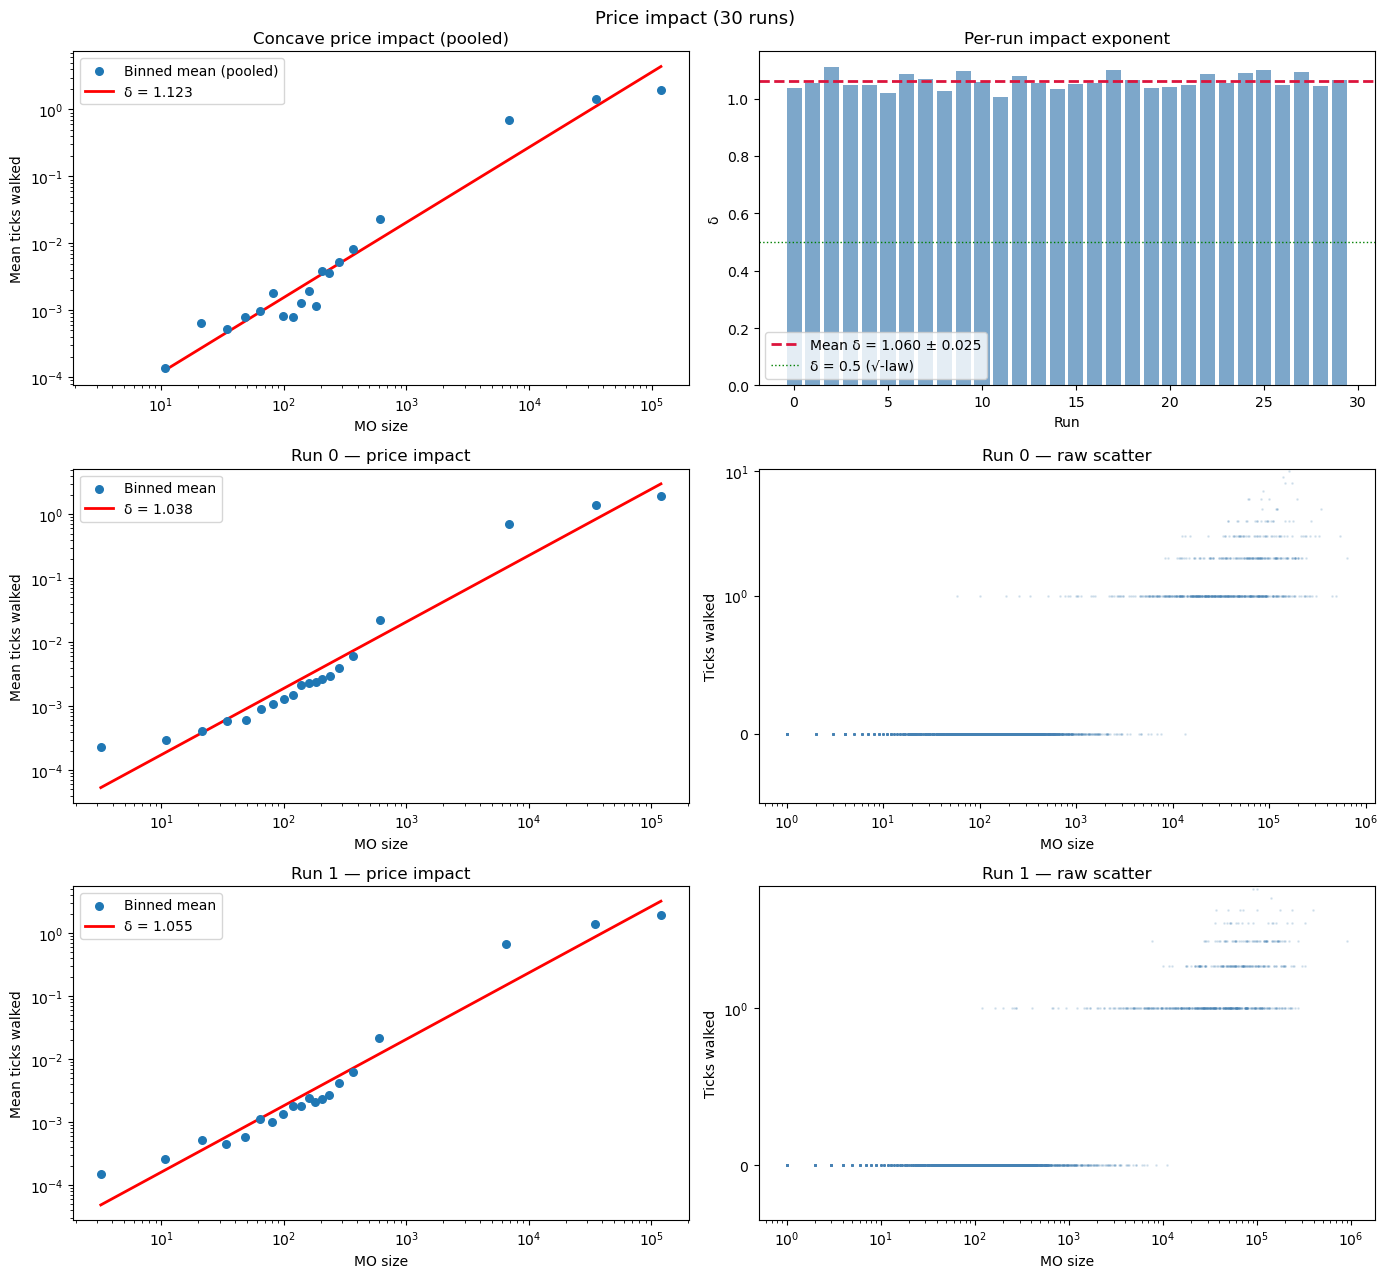

Pooled δ = 1.123  (benchmark ≈ 0.5)
Per-run δ: 1.060 ± 0.025  (min=1.007, max=1.109)
Total pooled MOs: 150,000


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# 6. Concave price impact
# ═══════════════════════════════════════════════════════════════════════

deltas  = mo["deltas"][~np.isnan(mo["deltas"])]
p_sizes = mo["pooled_sizes"]
p_tw    = mo["pooled_tw"]

# Bin pooled MO data
pcts = np.linspace(0, 100, N_BINS_IMPACT + 1)
bin_edges = np.unique(np.percentile(p_sizes, pcts))
bi = np.clip(np.digitize(p_sizes, bin_edges) - 1, 0, len(bin_edges) - 2)
ms_p, mi_p = [], []
for b in range(len(bin_edges) - 1):
    mask = bi == b
    if mask.sum() < 5:
        continue
    ms_p.append(p_sizes[mask].mean())
    mi_p.append(p_tw[mask].mean())
ms_p, mi_p = np.array(ms_p), np.array(mi_p)

n_ind = len(INDIVIDUAL_RUNS)
fig, axes = plt.subplots(1 + n_ind, 2, figsize=(14, 5 + 4 * n_ind))

# ── Row 0: aggregated ──────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(ms_p, mi_p, s=30, zorder=3, label="Binned mean (pooled)")
pos_p = mi_p > 0
delta_pooled = None
if pos_p.sum() >= 2:
    coef = np.polyfit(np.log10(ms_p[pos_p]), np.log10(mi_p[pos_p]), 1)
    delta_pooled = coef[0]
    xf = np.logspace(np.log10(ms_p[pos_p].min()),
                     np.log10(ms_p[pos_p].max()), 100)
    ax.plot(xf, 10**coef[1] * xf**delta_pooled, "r-", lw=2,
            label=f"δ = {delta_pooled:.3f}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("MO size"); ax.set_ylabel("Mean ticks walked")
ax.set_title("Concave price impact (pooled)"); ax.legend()

ax = axes[0, 1]
ax.bar(range(len(deltas)), deltas, alpha=0.7, color="steelblue")
ax.axhline(deltas.mean(), color="crimson", lw=2, ls="--",
           label=f"Mean δ = {deltas.mean():.3f} ± {deltas.std():.3f}")
ax.axhline(0.5, color="green", lw=1, ls=":", label="δ = 0.5 (√-law)")
ax.set_xlabel("Run"); ax.set_ylabel("δ")
ax.set_title("Per-run impact exponent"); ax.legend()

# ── Rows 1+: individual runs ──────────────────────────────────────
for row, run_idx in enumerate(INDIVIDUAL_RUNS):
    sizes_i = mo["sizes_individual"][run_idx]
    tw_i    = mo["tw_individual"][run_idx]

    be_i = np.unique(np.percentile(sizes_i, pcts))
    bi_i = np.clip(np.digitize(sizes_i, be_i) - 1, 0, len(be_i) - 2)
    ms_i, mi_i = [], []
    for b in range(len(be_i) - 1):
        mask = bi_i == b
        if mask.sum() < 5:
            continue
        ms_i.append(sizes_i[mask].mean())
        mi_i.append(tw_i[mask].mean())
    ms_i, mi_i = np.array(ms_i), np.array(mi_i)

    ax = axes[1 + row, 0]
    ax.scatter(ms_i, mi_i, s=30, zorder=3, label="Binned mean")
    pos_i = mi_i > 0
    if pos_i.sum() >= 2:
        coef_i = np.polyfit(np.log10(ms_i[pos_i]), np.log10(mi_i[pos_i]), 1)
        xf_i = np.logspace(np.log10(ms_i[pos_i].min()),
                           np.log10(ms_i[pos_i].max()), 100)
        ax.plot(xf_i, 10**coef_i[1] * xf_i**coef_i[0], "r-", lw=2,
                label=f"δ = {coef_i[0]:.3f}")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("MO size"); ax.set_ylabel("Mean ticks walked")
    ax.set_title(f"Run {run_idx} — price impact"); ax.legend()

    # scatter of raw data for this run
    ax = axes[1 + row, 1]
    sub = np.random.choice(len(sizes_i), min(5000, len(sizes_i)), replace=False)
    ax.scatter(sizes_i[sub], tw_i[sub], s=1, alpha=0.15, color="steelblue")
    ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=1)
    ax.set_xlabel("MO size"); ax.set_ylabel("Ticks walked")
    ax.set_title(f"Run {run_idx} — raw scatter")

plt.suptitle(f"Price impact ({N_RUNS} runs)", fontsize=13)
plt.tight_layout(); plt.show()

if delta_pooled is not None:
    print(f"Pooled δ = {delta_pooled:.3f}  (benchmark ≈ 0.5)")
print(f"Per-run δ: {deltas.mean():.3f} ± {deltas.std():.3f}  "
      f"(min={deltas.min():.3f}, max={deltas.max():.3f})")
print(f"Total pooled MOs: {len(p_sizes):,}")

In [ ]:

ROOT = Path.cwd().resolve().parent
OUTPUT_DIR = ROOT / "data"

TICK_SIZE = 0.05


db_path = OUTPUT_DIR / "sim_events_single_full_10M_8.sqlite"

am = AnalyseMarket(db_path, tick_size=TICK_SIZE)

# ─────────────────────────────────────────────────────────────
# For SIMULATION DATA, use the simulation database instead:
#   am = AnalyseMarket("sim_events.sqlite", tick_size=0.01)
# ─────────────────────────────────────────────────────────────

AnalyseMarket | sim_events_single_full_10M_8.sqlite | simulation
  Tables: ['bbo', 'fills', 'intensities', 'mo_orders', 'orders']


## Triple kernel sim results

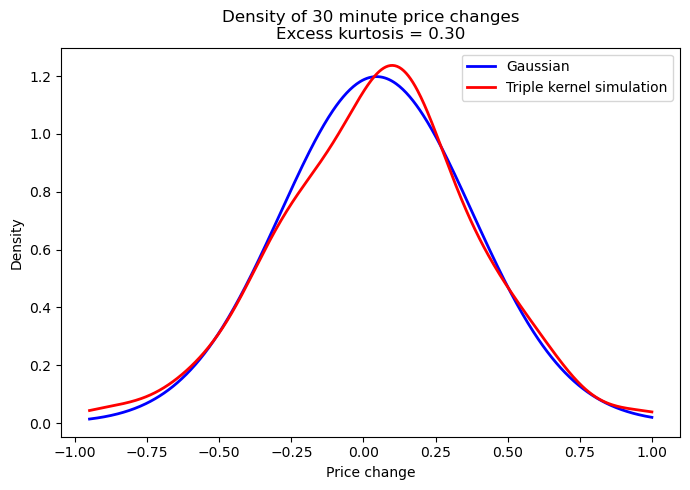

Interval: 30 min  |  n_changes: 156  |  changes='level'  |  Excess kurtosis: 0.30


In [5]:
am.stylized_fat_tails(label="Triple kernel simulation")

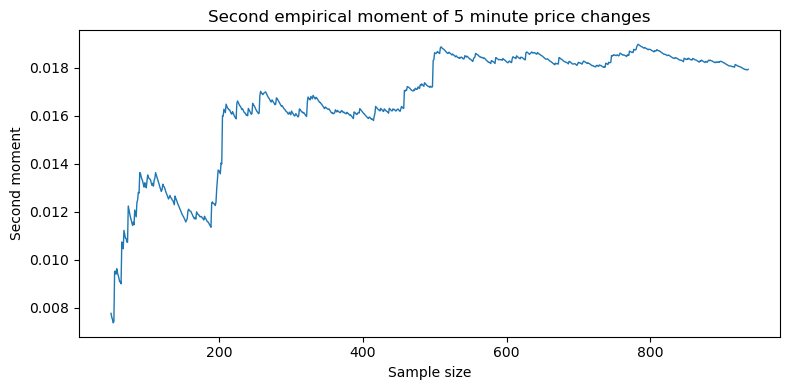

Interval: 5 min  |  n_changes: 936  |  Final M₂: 0.017939


In [6]:
am.stylized_moment_instability()

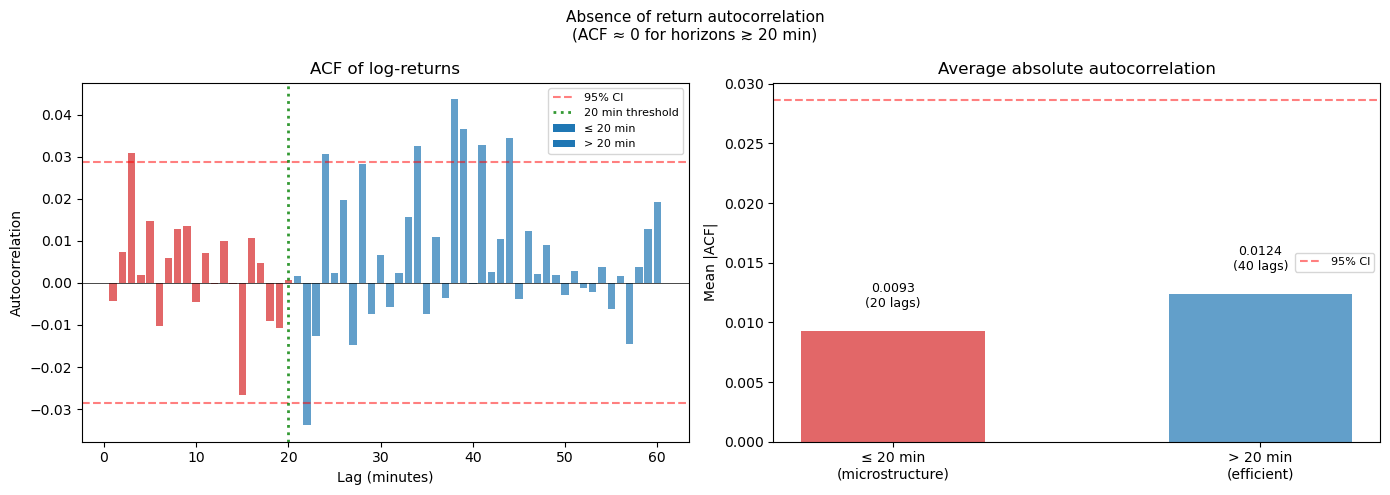

Sampling interval: 1 min
Mean |ACF| ≤ 20 min: 0.0093  (20 lags)
Mean |ACF| > 20 min: 0.0124  (40 lags)


In [7]:
am.stylized_return_autocorrelation()

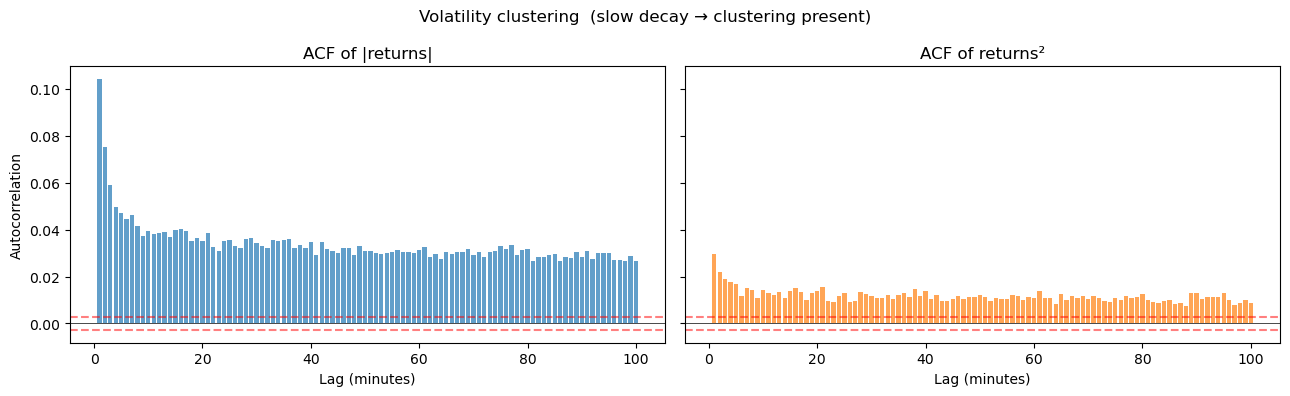

|returns| ACF half-life ≈ 9 min
|returns| ACF(1 min) = 0.1042,  ACF(10 min) = 0.0395


In [19]:
am.stylized_volatility_clustering()

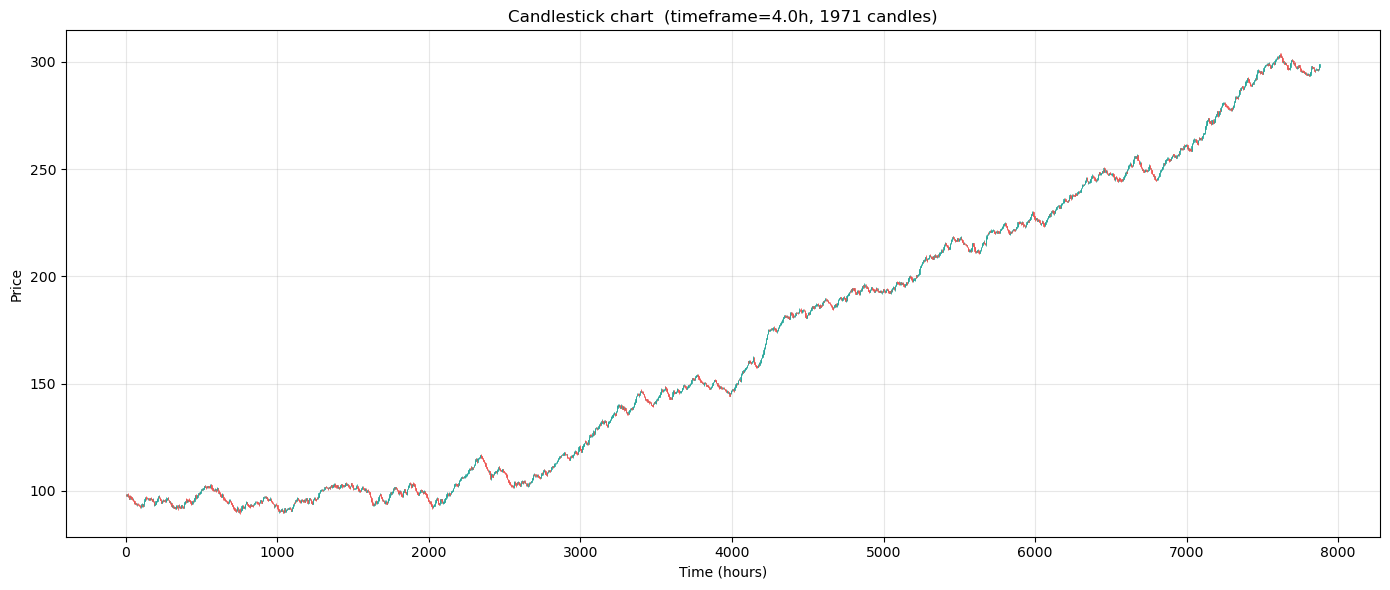

In [20]:
am.plot_candlestick(timeframe=14400.0)